In [42]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder  # Encoders nativos do sklearn
from sklearn.model_selection import train_test_split            # Divisão de dados em treino/teste
from sklearn.ensemble import RandomForestClassifier             # Modelo de classificação ensemble
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Métricas de avaliação

# =============================================================================
# BIBLIOTECAS DE ENCODING AVANÇADO
# =============================================================================
from category_encoders import BinaryEncoder  # Biblioteca para Binary Encoding

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

# Parte 1 - Leitura + EDA

In [43]:
# Leitura correta do CSV (separador, decimal, encoding)
df = pd.read_csv(r'C:\Users\gabri\OneDrive\Documentos\MBA\Trabalhos\Applied Statistics\Base_ScoreCredito_QuantumFinance(8).csv', sep = ";")


In [44]:
# Identificar o target e documentar todas as variáveis (o que cada uma significa)
df

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
0,708082083,45,F,casado,graduacao,3,40,1,"40,089665024322",3,0,0,1,1,778
1,708083283,58,M,solteiro,ensino fundam,0,44,1,"66,557645274838",3,0,0,1,0,"276,3"
2,708084558,46,M,divorciado,doutorado,3,35,1,"123,68182089138",6,0,0,1,1,401
3,708085458,34,F,solteiro,mestrado,0,22,1,"19,7159343168329",6,0,0,1,0,"347,4"
4,708086958,49,F,casado,mestrado,2,36,0,0,3,1,437,1,2,476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,828288333,50,M,casado,mestrado,0,45,1,"100,128970755",4,0,0,1,0,470
10123,828291858,38,M,solteiro,ensino fundam,0,31,1,"89,80599574656",6,0,0,1,1,432
10124,828294933,49,F,casado,graduacao,3,43,1,"19,7993057098452",3,1,252,1,1,406
10125,828298908,54,M,casado,ensino medio,4,48,1,"194,78317642784",4,0,0,1,1,387


In [45]:
y = df["SCORE_CREDITO"]
X = df.drop(columns = "SCORE_CREDITO")

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   10127 non-null  int64
 1   idade                10127 non-null  int64
 2   sexo                 10127 non-null  str  
 3   estado_civil         10127 non-null  str  
 4   escola               10127 non-null  str  
 5   Qte_dependentes      10127 non-null  int64
 6   tempo_ultimoservico  10127 non-null  int64
 7   trabalha             10127 non-null  int64
 8   vl_salario_mil       10127 non-null  str  
 9   reg_moradia          10127 non-null  int64
 10  casa_propria         10127 non-null  int64
 11  vl_imovel_em_mil     10127 non-null  int64
 12  Qte_cartoes          10127 non-null  int64
 13  Qte_carros           10127 non-null  int64
 14  SCORE_CREDITO        10127 non-null  str  
dtypes: int64(10), str(5)
memory usage: 1.2 MB


In [47]:
print(df['SCORE_CREDITO'].unique()[:20])   # primeiros 20 valores distintos
print(df['SCORE_CREDITO'].nunique())         # quantos valores distintos existem

<StringArray>
[  '778', '276,3',   '401', '347,4',   '476', '522,9',   '186', '377,1',
 '502,2', '804,6',   '407',   '284',   '479',   '435',   '345',   '433',
   '533', '598,5',   '478', '567,9']
Length: 20, dtype: str
1864


In [48]:
df['SCORE_CREDITO'] = df['SCORE_CREDITO'].str.replace(',', '.').astype(float)
df['vl_salario_mil'] = df['vl_salario_mil'].str.replace(',', '.').astype(float)

In [49]:
df.describe(include='all')

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
count,1.012700e+04,10127.000000,10127,10127,10127,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
unique,NaN,NaN,2,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,F,casado,ensino medio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5358,4687,3352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.391776e+08,46.325960,NaN,NaN,NaN,1.547447,34.133208,0.911919,70.209002,3.783450,0.352424,208.999111,1.083638,0.623383,469.500364
std,3.690378e+07,8.016814,NaN,NaN,NaN,1.489079,8.221428,0.283427,55.567032,1.580486,0.477749,378.495229,0.333784,0.569796,133.814653
min,7.080821e+08,26.000000,NaN,NaN,NaN,0.000000,7.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,162.000000
25%,7.130368e+08,41.000000,NaN,NaN,NaN,0.000000,30.000000,1.000000,21.330536,3.000000,0.000000,0.000000,1.000000,0.000000,375.000000
50%,7.179264e+08,46.000000,NaN,NaN,NaN,1.000000,34.000000,1.000000,66.486331,4.000000,0.000000,0.000000,1.000000,1.000000,449.600000
75%,7.731435e+08,52.000000,NaN,NaN,NaN,3.000000,39.000000,1.000000,107.544225,5.000000,1.000000,289.000000,1.000000,1.000000,540.900000


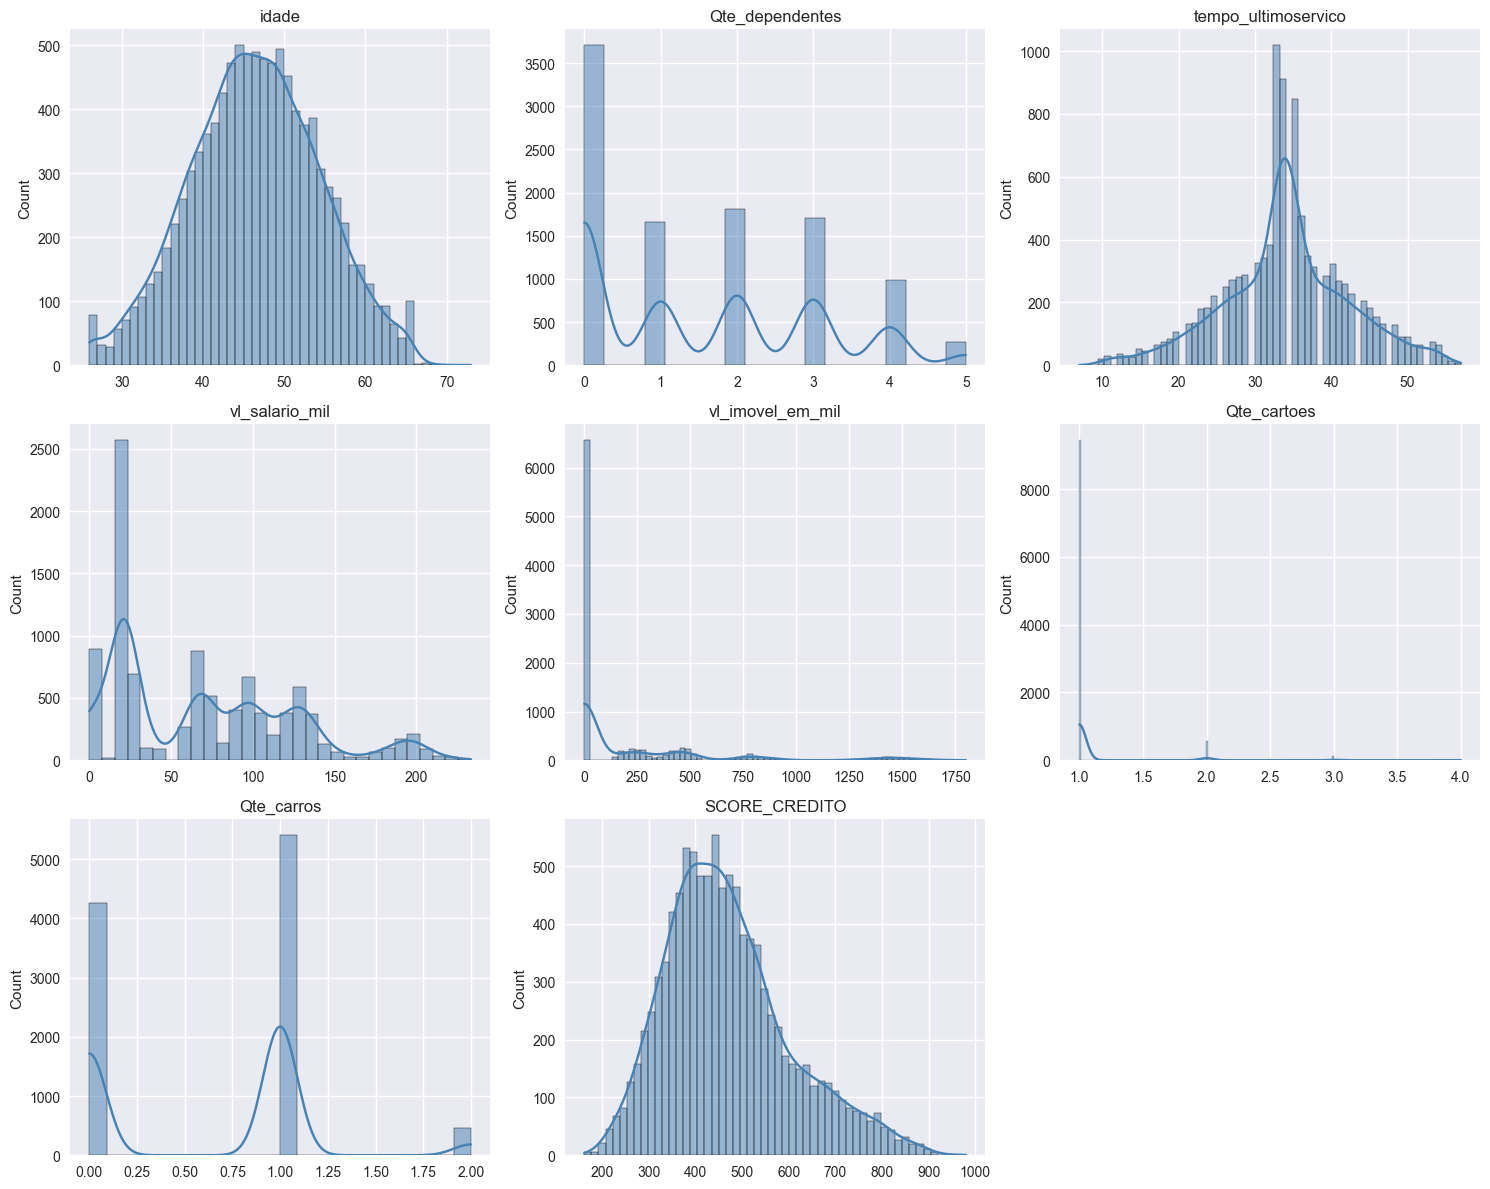

In [50]:
# Distribuição das variáveis quantitativas

colunas = df.select_dtypes(include="number").columns.drop(["id", "trabalha", "reg_moradia", "casa_propria"])

n = len(colunas)
n_cols = 3
n_linhas = (n + n_cols -1) // n_cols

fig, axes = plt.subplots(n_linhas, n_cols, figsize = (15, 4 * n_linhas))
axes = axes.flatten()

for i, col in enumerate(colunas):
    sns.histplot(df[col], kde = True, ax = axes[i], color = "steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for x in range(i + 1, len(axes)):
    fig.delaxes(axes[x])

plt.tight_layout()
plt.show();

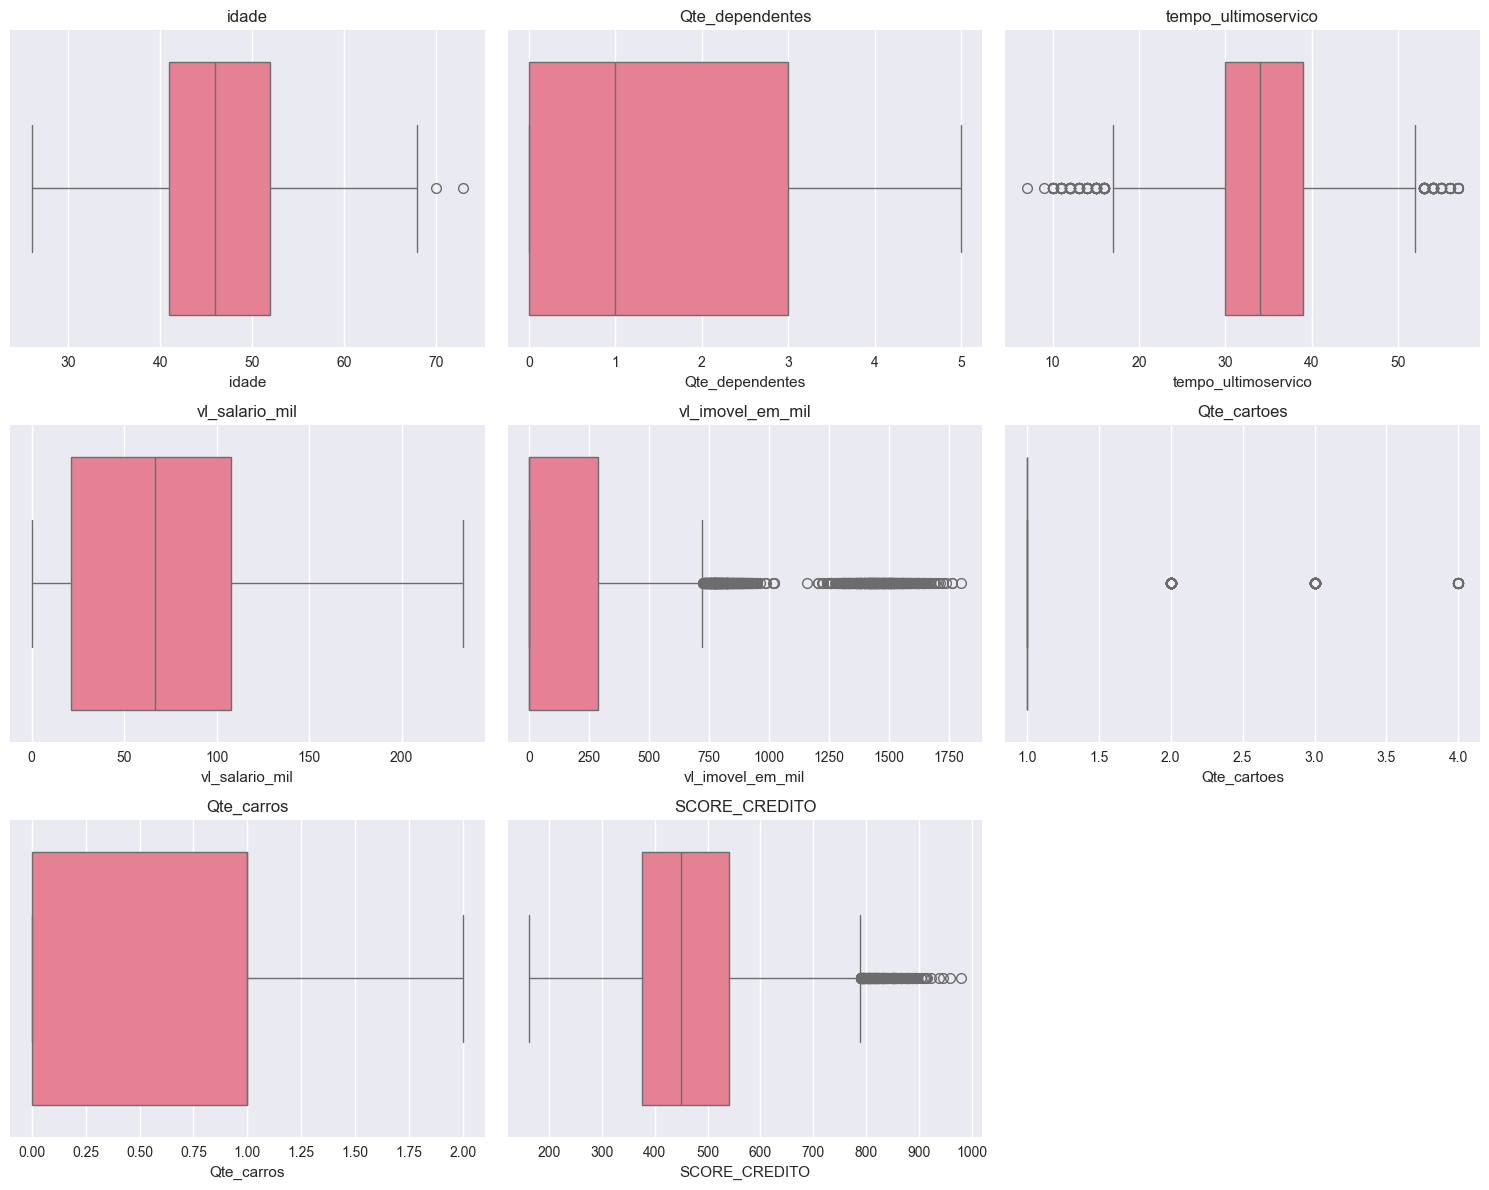

In [51]:
# Tratamento de outliers nas Quantitativas:
colunas_numericas = df.select_dtypes(include = "number").drop(columns = ["id", "trabalha", "casa_propria", "reg_moradia"]).columns
n = len(colunas_numericas)
n_cols = 3
n_linhas = (n + n_cols - 1) // n_cols   # arredonda pra cima

fig, axes = plt.subplots(n_linhas, n_cols, figsize=(15, 4 * n_linhas))
axes = axes.flatten()   # transforma a grade num vetor pra iterar fácil

for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(x=df[coluna], ax=axes[i])
    axes[i].set_title(coluna)

# remove os quadros vazios que sobram na grade
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [52]:
for col in ['vl_imovel_em_mil', 'tempo_ultimoservico', 'SCORE_CREDITO']:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQ = Q3 - Q1

    lim_15_sup, lim_3_sup = Q3 + 1.5*IQ, Q3 + 3*IQ
    lim_15_inf, lim_3_inf = Q1 - 1.5*IQ, Q1 - 3*IQ

    mod_sup = ((df[col] > lim_15_sup) & (df[col] <= lim_3_sup)).sum()
    ext_sup = (df[col] > lim_3_sup).sum()
    mod_inf = ((df[col] < lim_15_inf) & (df[col] >= lim_3_inf)).sum()
    ext_inf = (df[col] < lim_3_inf).sum()

    print(f"\n{col}:")
    print(f"  Superiores  -> moderados: {mod_sup}, extremos: {ext_sup}")
    print(f"  Inferiores  -> moderados: {mod_inf}, extremos: {ext_inf}")
    print(f"  TOTAL outliers (1.5×IQR): {mod_sup+ext_sup+mod_inf+ext_inf}")


vl_imovel_em_mil:
  Superiores  -> moderados: 533, extremos: 562
  Inferiores  -> moderados: 0, extremos: 0
  TOTAL outliers (1.5×IQR): 1095

tempo_ultimoservico:
  Superiores  -> moderados: 187, extremos: 0
  Inferiores  -> moderados: 240, extremos: 0
  TOTAL outliers (1.5×IQR): 427

SCORE_CREDITO:
  Superiores  -> moderados: 248, extremos: 0
  Inferiores  -> moderados: 0, extremos: 0
  TOTAL outliers (1.5×IQR): 248


In [53]:
print(df['vl_imovel_em_mil'].describe())
print("Zeros:", (df['vl_imovel_em_mil'] == 0).sum())
print("Assimetria:", df['vl_imovel_em_mil'].skew())
print("Assimetria tempo_ultimoservico:", df['tempo_ultimoservico'].skew())

count    10127.000000
mean       208.999111
std        378.495229
min          0.000000
25%          0.000000
50%          0.000000
75%        289.000000
max       1800.000000
Name: vl_imovel_em_mil, dtype: float64
Zeros: 6558
Assimetria: 2.179424667963753
Assimetria tempo_ultimoservico: -0.06049179350587253


In [54]:
# Transformação da variável Valor do imovel em log pela alta assimetria:

df['vl_imovel_log'] = np.log1p(df['vl_imovel_em_mil'])


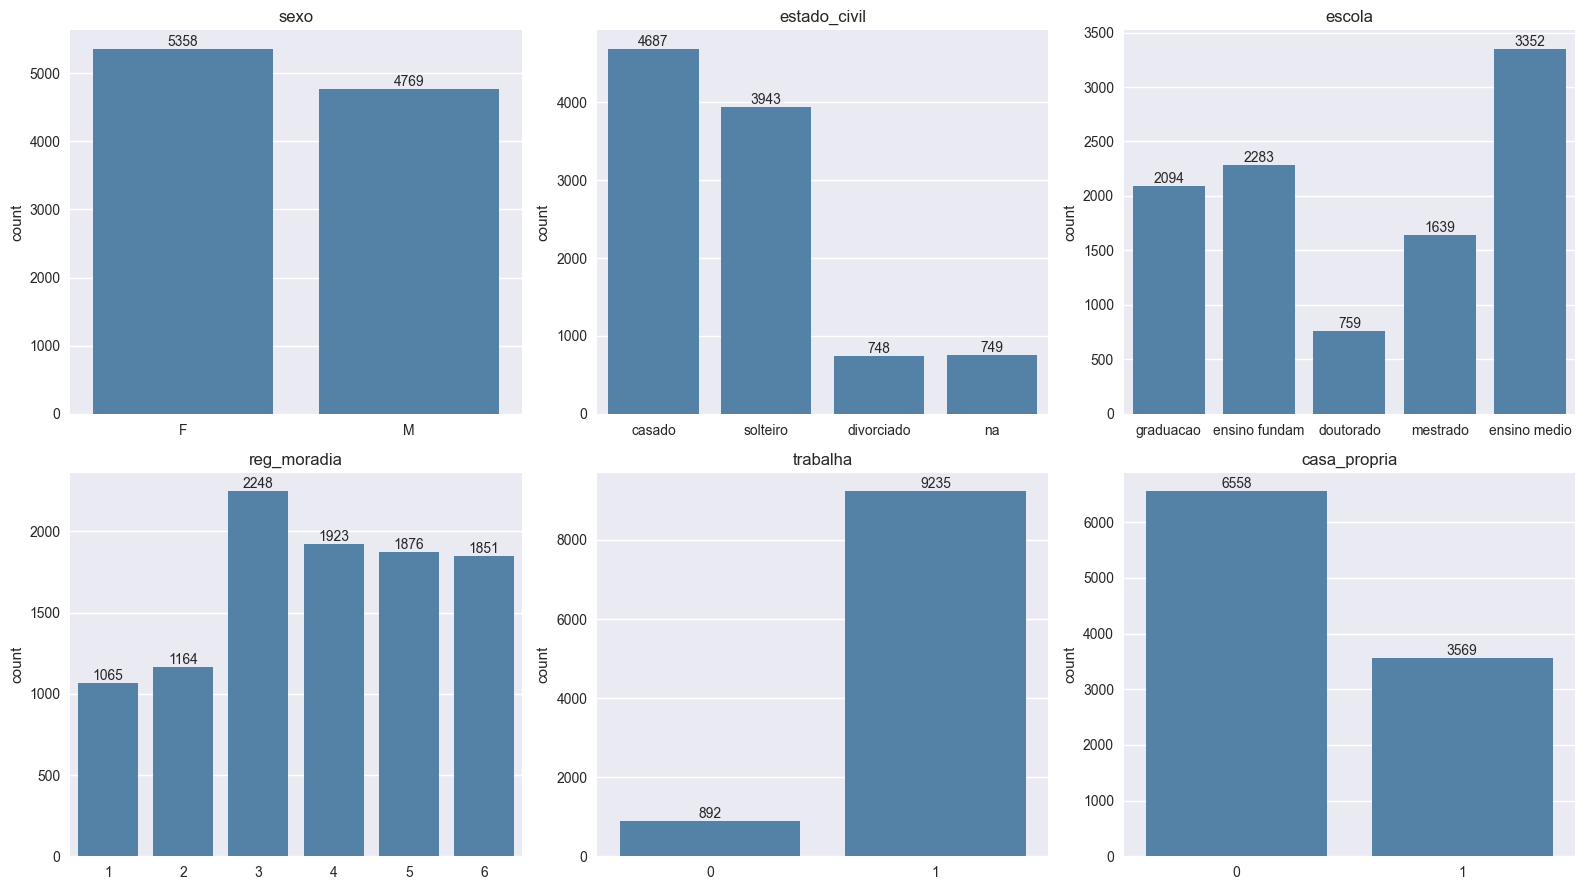

In [55]:
# Countplot para variáveis qualitativas:

categoricas = ['sexo', 'estado_civil', 'escola', 'reg_moradia',
               'trabalha', 'casa_propria']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df, x=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    # rótulo de contagem em cima de cada barra
    for container in axes[i].containers:
        axes[i].bar_label(container)

plt.tight_layout()
plt.show()

In [56]:
# Investigação dos valores NA em estado_civil:

print(df['estado_civil'].unique())
print((df['estado_civil'] == 'na').sum())
print(f"{(df['estado_civil'] == 'na').mean() * 100:.1f}%")

# Manter na pois seria uma perda muito grande da amostra

df['estado_civil'] = df['estado_civil'].replace('na', 'nao_informado')

<StringArray>
['casado', 'solteiro', 'divorciado', 'na']
Length: 4, dtype: str
749
7.4%


In [57]:
# Tratamento de nulos
df.isna().sum().sort_values(ascending=False)

id                     0
idade                  0
sexo                   0
estado_civil           0
escola                 0
Qte_dependentes        0
tempo_ultimoservico    0
trabalha               0
vl_salario_mil         0
reg_moradia            0
casa_propria           0
vl_imovel_em_mil       0
Qte_cartoes            0
Qte_carros             0
SCORE_CREDITO          0
vl_imovel_log          0
dtype: int64

# Parte 2 - Correlação + Logística

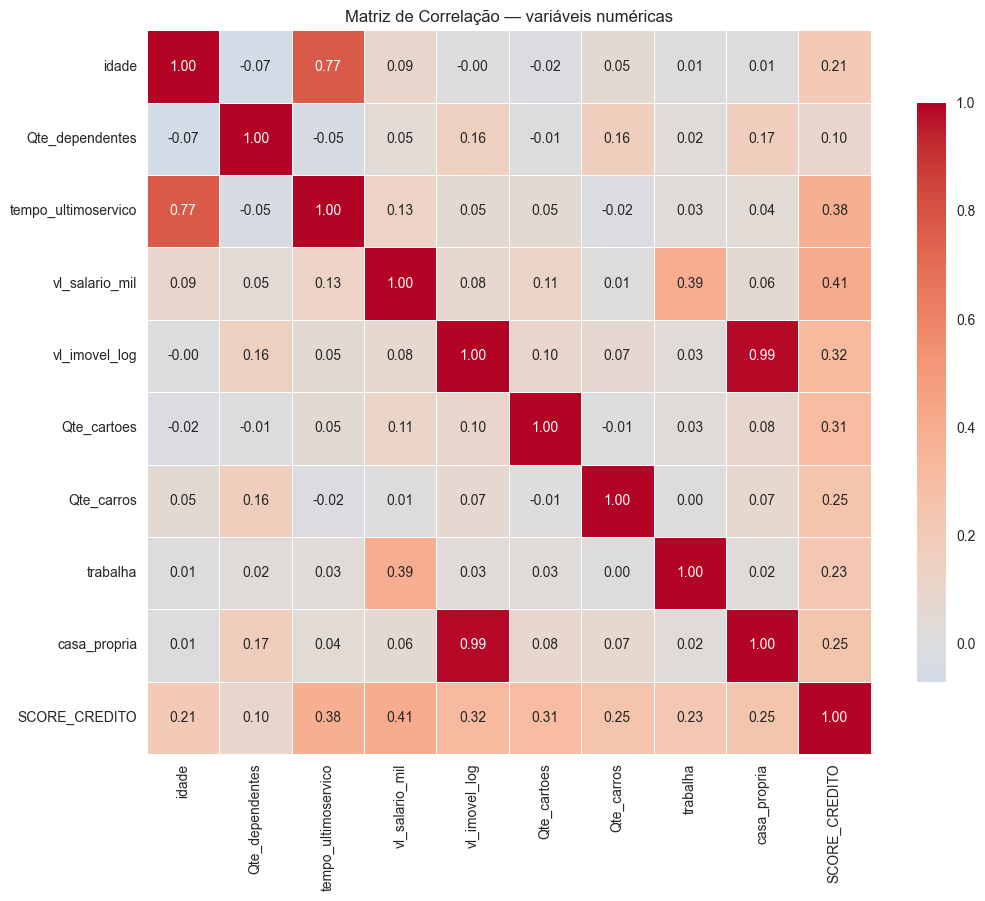

In [58]:
# Correlação com os dados quantitativos:

num_corr = ['idade', 'Qte_dependentes', 'tempo_ultimoservico',
            'vl_salario_mil', 'vl_imovel_log', 'Qte_cartoes',
            'Qte_carros', 'trabalha', 'casa_propria', 'SCORE_CREDITO']

corr = df[num_corr].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação — variáveis numéricas')
plt.tight_layout()
plt.show()

In [59]:
for col in ['sexo', 'estado_civil', 'escola', 'reg_moradia']:
    print(f"\n=== SCORE médio por {col} ===")
    print(df.groupby(col)['SCORE_CREDITO'].mean().sort_values())


=== SCORE médio por sexo ===
sexo
F    442.007309
M    500.388976
Name: SCORE_CREDITO, dtype: float64

=== SCORE médio por estado_civil ===
estado_civil
solteiro         450.747539
casado           476.336147
divorciado       494.775869
nao_informado    500.203965
Name: SCORE_CREDITO, dtype: float64

=== SCORE médio por escola ===
escola
ensino fundam    429.601743
graduacao        471.991681
ensino medio     477.587918
mestrado         486.558557
doutorado        510.085178
Name: SCORE_CREDITO, dtype: float64

=== SCORE médio por reg_moradia ===
reg_moradia
5    439.355034
6    439.872176
4    440.864552
3    453.724560
2    530.968588
1    591.919213
Name: SCORE_CREDITO, dtype: float64


In [60]:
print(df.groupby('reg_moradia')['SCORE_CREDITO'].mean().sort_values())

reg_moradia
5    439.355034
6    439.872176
4    440.864552
3    453.724560
2    530.968588
1    591.919213
Name: SCORE_CREDITO, dtype: float64


# Parte 3 - Modelo e Simulador

In [61]:
# Cópia de seguranç:
df_model = df.copy()

In [62]:
# target convertido de texto para número (vírgula -> ponto)
# se já converteu no df original, a cópia já traz. Confirme o tipo:
print(df_model['SCORE_CREDITO'].dtype)   # deve ser float64

# versão log do imóvel
import numpy as np
df_model['vl_imovel_log'] = np.log1p(df_model['vl_imovel_em_mil'])

# tratamento do 'na' no estado_civil
df_model['estado_civil'] = df_model['estado_civil'].replace('na', 'nao_informado')

float64


In [63]:
# Separação do modelo em teste e treino

y = df_model['SCORE_CREDITO']
X = df_model.drop(columns=['SCORE_CREDITO', 'id', 'vl_imovel_em_mil', 'casa_propria'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)
print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")
print(f"Proporção de sobreviventes no treino: {y_train.mean():.3f}")
print(f"Proporção de sobreviventes no teste: {y_test.mean():.3f}")

Tamanho do conjunto de treino: 7088 amostras
Tamanho do conjunto de teste: 3039 amostras
Proporção de sobreviventes no treino: 469.410
Proporção de sobreviventes no teste: 469.711


In [64]:
# Enconding: Sexo

one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

col_nominais = ['sexo', 'estado_civil', 'reg_moradia']

X_train_onehot_encoded = one_hot_encoder.fit_transform(X_train[col_nominais])
X_test_onehot_encoded = one_hot_encoder.transform(X_test[col_nominais])

onehot_feature_names = one_hot_encoder.get_feature_names_out(col_nominais)

onehot_train_df = pd.DataFrame(X_train_onehot_encoded, columns=onehot_feature_names, index=X_train.index)
onehot_test_df = pd.DataFrame(X_test_onehot_encoded, columns=onehot_feature_names, index=X_test.index)

print("Colunas criadas pelo One-Hot Encoding:")
print(onehot_feature_names)
print(f"\nPrimeiras linhas do conjunto de treino após One-Hot Encoding:")
onehot_train_df.head()

Colunas criadas pelo One-Hot Encoding:
['sexo_M' 'estado_civil_divorciado' 'estado_civil_nao_informado'
 'estado_civil_solteiro' 'reg_moradia_2' 'reg_moradia_3' 'reg_moradia_4'
 'reg_moradia_5' 'reg_moradia_6']

Primeiras linhas do conjunto de treino após One-Hot Encoding:


,sexo_M,estado_civil_divorciado,estado_civil_nao_informado,estado_civil_solteiro,reg_moradia_2,reg_moradia_3,reg_moradia_4,reg_moradia_5,reg_moradia_6
415,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3749,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9295,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8290,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7672,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [65]:
# Juntando as variáveis aos X_train e X_test

X_train_final = pd.concat([
    X_train.drop(columns=col_nominais),
    onehot_train_df
], axis=1)

X_test_final = pd.concat([
    X_test.drop(columns=col_nominais),
    onehot_test_df
], axis=1)

In [66]:
print("Treino:", X_train_final.shape)
print("Teste:", X_test_final.shape)

Treino: (7088, 18)
Teste: (3039, 18)


In [67]:
print("Índice X e y batem (treino)?", (X_train_final.index == y_train.index).all())
print("Índice X e y batem (teste)?", (X_test_final.index == y_test.index).all())

Índice X e y batem (treino)? True
Índice X e y batem (teste)? True


In [68]:
print("Nulos no treino:", X_train_final.isna().sum().sum())
print("Nulos no teste:", X_test_final.isna().sum().sum())

Nulos no treino: 0
Nulos no teste: 0


In [69]:
print(X_train_final.dtypes)

idade                           int64
escola                            str
Qte_dependentes                 int64
tempo_ultimoservico             int64
trabalha                        int64
vl_salario_mil                float64
Qte_cartoes                     int64
Qte_carros                      int64
vl_imovel_log                 float64
sexo_M                        float64
estado_civil_divorciado       float64
estado_civil_nao_informado    float64
estado_civil_solteiro         float64
reg_moradia_2                 float64
reg_moradia_3                 float64
reg_moradia_4                 float64
reg_moradia_5                 float64
reg_moradia_6                 float64
dtype: object


In [70]:
# Encoding ordinal da escolaridade:

ordinal_encoder = OrdinalEncoder(
    categories=[['ensino fundam', 'ensino medio', 'graduacao', 'mestrado', 'doutorado']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

categorical_cols_ordinal = ['escola']

X_train_final['escola'] = ordinal_encoder.fit_transform(X_train[categorical_cols_ordinal])
X_test_final['escola'] = ordinal_encoder.transform(X_test[categorical_cols_ordinal])

print("Mapeamento das categorias (Ordinal Encoding):")
for i, col in enumerate(categorical_cols_ordinal):
    categories = ordinal_encoder.categories_[i]
    print(f"{col}: {dict(zip(categories, range(len(categories))))}")

Mapeamento das categorias (Ordinal Encoding):
escola: {'ensino fundam': 0, 'ensino medio': 1, 'graduacao': 2, 'mestrado': 3, 'doutorado': 4}


In [71]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_final)
X_test_sm = sm.add_constant(X_test_final)

In [ ]:
# Criação do modelo e treino

modelo = sm.OLS(y_train, X_train_sm)

resultado = modelo.fit()
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     442.6
Date:                sáb, 04 jul 2026   Prob (F-statistic):               0.00
Time:                        20:19:07   Log-Likelihood:                -42087.
No. Observations:                7088   AIC:                         8.421e+04
Df Residuals:                    7069   BIC:                         8.434e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [ ]:
# Resultados do modelo com teste

y_pred = resultado.predict(X_test_sm)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²   no teste: {r2:.4f}")
print(f"RMSE no teste: {rmse:.2f}")
print(f"MAE  no teste: {mae:.2f}")
print(f"\nR² treino: {resultado.rsquared:.4f}")
print(f"R² teste:  {r2:.4f}")

R²   no teste: 0.4823
RMSE no teste: 96.32
MAE  no teste: 75.47

R² treino: 0.5299
R² teste:  0.4823


In [77]:
from sklearn.tree import DecisionTreeRegressor

# random_state para reprodutibilidade
arvore = DecisionTreeRegressor(random_state=42)
arvore.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [78]:
y_pred_arvore = arvore.predict(X_test_final)

r2_arvore = r2_score(y_test, y_pred_arvore)
rmse_arvore = np.sqrt(mean_squared_error(y_test, y_pred_arvore))
mae_arvore = mean_absolute_error(y_test, y_pred_arvore)

print(f"R²   árvore (teste): {r2_arvore:.4f}")
print(f"RMSE árvore (teste): {rmse_arvore:.2f}")
print(f"MAE  árvore (teste): {mae_arvore:.2f}")

R²   árvore (teste): 0.5740
RMSE árvore (teste): 87.38
MAE  árvore (teste): 63.63


In [79]:
y_pred_treino_arvore = arvore.predict(X_train_final)
print(f"R² árvore (treino): {r2_score(y_train, y_pred_treino_arvore):.4f}")

R² árvore (treino): 0.9998


In [80]:
# Teste com Random Forest

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [81]:
# teste
y_pred_rf = rf.predict(X_test_final)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# treino (pra medir o gap)
r2_rf_treino = r2_score(y_train, rf.predict(X_train_final))

print(f"R²   RF (teste):  {r2_rf:.4f}")
print(f"RMSE RF (teste):  {rmse_rf:.2f}")
print(f"MAE  RF (teste):  {mae_rf:.2f}")
print(f"\nR² RF (treino):   {r2_rf_treino:.4f}")
print(f"R² RF (teste):    {r2_rf:.4f}")
print(f"Gap treino-teste: {r2_rf_treino - r2_rf:.4f}")

R²   RF (teste):  0.7804
RMSE RF (teste):  62.74
MAE  RF (teste):  46.37

R² RF (treino):   0.9711
R² RF (teste):    0.7804
Gap treino-teste: 0.1907


In [82]:
importancias = pd.DataFrame({
    'variavel': X_train_final.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias)

                      variavel  importancia
8                vl_imovel_log     0.360651
5               vl_salario_mil     0.272865
3          tempo_ultimoservico     0.123164
7                   Qte_carros     0.063739
0                        idade     0.060740
6                  Qte_cartoes     0.038895
2              Qte_dependentes     0.017769
1                       escola     0.017236
12       estado_civil_solteiro     0.009605
14               reg_moradia_3     0.005629
9                       sexo_M     0.005371
15               reg_moradia_4     0.004364
16               reg_moradia_5     0.004254
17               reg_moradia_6     0.004098
10     estado_civil_divorciado     0.004051
11  estado_civil_nao_informado     0.003560
13               reg_moradia_2     0.003146
4                     trabalha     0.000862
